# 🔄 Customer Churn Prediction — Upgraded Pipeline
### End-to-End ML System with Explainable AI, Dynamic Risk Scoring & Personalized Retention Recommendations

**Upgrade Features:**
- Advanced Feature Engineering
- Hybrid Ensemble Modelling (RF + XGBoost + LightGBM + Logistic Regression)
- Dynamic Churn Risk Scoring (Low / Medium / High)
- SHAP-based Explainable AI
- Automated Personalized Retention Recommendation Engine
- End-to-End Prediction Pipeline
- Model + Encoder + Scaler Persistence


## 1. Import Dependencies

In [1]:
# Core
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)

# Explainable AI
import shap

# Persistence
import pickle, os

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


## 2. Data Loading & Initial Understanding

In [2]:
# ── Load Dataset ──────────────────────────────────────────
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f"Dataset shape: {df.shape}")
df.head(3)


Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [3]:
# Basic info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Class distribution
print("Churn distribution:")
print(df['Churn'].value_counts())
print(f"\nClass ratio (No:Yes) = {df['Churn'].value_counts()[0]}:{df['Churn'].value_counts()[1]}")


Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Class ratio (No:Yes) = 5174:1869


## 3. Data Cleaning & Missing Value Handling

In [5]:
# Drop CustomerID — not needed for modelling
df.drop(columns=['customerID'], inplace=True)

# Fix TotalCharges — coerce blanks to NaN, then fill with 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
missing_tc = df['TotalCharges'].isnull().sum()
print(f"Missing TotalCharges values: {missing_tc}")
df['TotalCharges'].fillna(0.0, inplace=True)

# Check remaining nulls
print("\nNull counts after cleaning:")
print(df.isnull().sum().sum(), "total nulls remaining")

# Encode target variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print("\n✅ Data cleaning complete.")


Missing TotalCharges values: 11

Null counts after cleaning:
0 total nulls remaining

✅ Data cleaning complete.


## 4. Advanced Preprocessing — Outlier Handling

In [6]:
def cap_outliers_iqr(df, col):
    """Cap outliers using IQR method (Winsorisation)."""
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f"  {col}: {before} outliers capped  →  range [{lower:.2f}, {upper:.2f}]")
    return df

numerical_cols = ['MonthlyCharges', 'TotalCharges', 'tenure']
print("Outlier capping (IQR Winsorisation):")
for col in numerical_cols:
    df = cap_outliers_iqr(df, col)

print("\n✅ Outlier handling complete.")


Outlier capping (IQR Winsorisation):
  MonthlyCharges: 0 outliers capped  →  range [-46.02, 171.38]
  TotalCharges: 0 outliers capped  →  range [-4683.52, 8868.67]
  tenure: 0 outliers capped  →  range [-60.00, 124.00]

✅ Outlier handling complete.


## 5. Feature Engineering

In [7]:
# ── 5.1  Derived Numeric Features ─────────────────────────
# AverageMonthlySpend — avoid div-by-zero when tenure=0
df['AverageMonthlySpend'] = np.where(
    df['tenure'] > 0,
    df['TotalCharges'] / df['tenure'],
    df['MonthlyCharges']
)

# ChargeToTenureRatio
df['ChargeToTenureRatio'] = df['MonthlyCharges'] / (df['tenure'] + 1)

# ── 5.2  Service Count ────────────────────────────────────
service_cols = ['PhoneService', 'MultipleLines', 'InternetService',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

def count_services(row):
    count = 0
    for col in service_cols:
        val = str(row[col]).strip().lower()
        if val not in ['no', 'no phone service', 'no internet service']:
            count += 1
    return count

df['ServiceCount'] = df.apply(count_services, axis=1)

# ── 5.3  Customer Engagement Score ───────────────────────
# Weighted composite: tenure + services - charge pressure
df['CustomerEngagementScore'] = (
    (df['tenure'] / df['tenure'].max()) * 0.4 +
    (df['ServiceCount'] / len(service_cols)) * 0.4 -
    (df['ChargeToTenureRatio'] / df['ChargeToTenureRatio'].max()) * 0.2
)

# ── 5.4  Contract-based Churn Indicator ──────────────────
df['IsMonthToMonth'] = (df['Contract'] == 'Month-to-month').astype(int)
df['HasLongContract'] = (df['Contract'].isin(['One year', 'Two year'])).astype(int)

# ── 5.5  Tenure Group Buckets ─────────────────────────────
def tenure_group(t):
    if t <= 6:   return 'New'        # 0-6 months
    elif t <= 12: return 'Growing'   # 6-12 months
    elif t <= 24: return 'Stable'    # 12-24 months
    else:         return 'Loyal'     # 24+ months

df['TenureGroup'] = df['tenure'].apply(tenure_group)

print("New feature columns created:")
new_feats = ['AverageMonthlySpend', 'ChargeToTenureRatio', 'ServiceCount',
             'CustomerEngagementScore', 'IsMonthToMonth', 'HasLongContract', 'TenureGroup']
print(df[new_feats].head(5))
print("\n✅ Feature engineering complete.")


New feature columns created:
   AverageMonthlySpend  ChargeToTenureRatio  ServiceCount  \
0            29.850000            14.925000             2   
1            55.573529             1.627143             4   
2            54.075000            17.950000             4   
3            40.905556             0.919565             4   
4            75.825000            23.566667             2   

   CustomerEngagementScore  IsMonthToMonth  HasLongContract TenureGroup  
0                 0.057524               1                0         New  
1                 0.362642               0                1       Loyal  
2                 0.144486               1                0         New  
3                 0.425503               0                1       Loyal  
4                 0.041703               1                0         New  

✅ Feature engineering complete.


## 6. Exploratory Data Analysis (EDA)

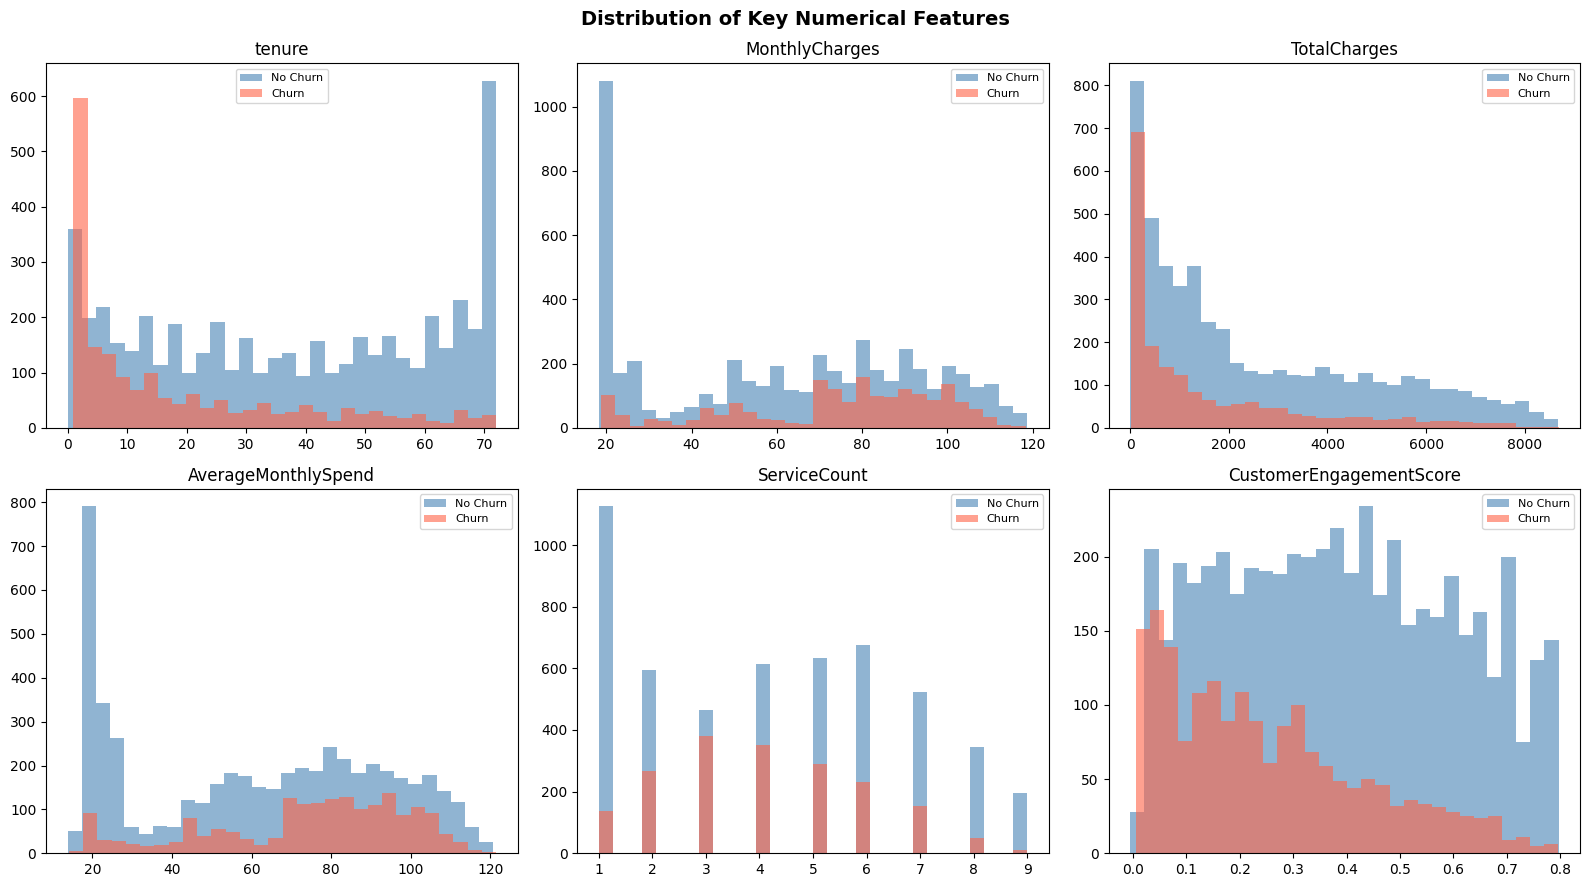

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribution of Key Numerical Features', fontsize=14, fontweight='bold')

num_features = ['tenure', 'MonthlyCharges', 'TotalCharges',
                'AverageMonthlySpend', 'ServiceCount', 'CustomerEngagementScore']

for ax, col in zip(axes.flatten(), num_features):
    churn_0 = df[df['Churn']==0][col]
    churn_1 = df[df['Churn']==1][col]
    ax.hist(churn_0, bins=30, alpha=0.6, color='steelblue', label='No Churn')
    ax.hist(churn_1, bins=30, alpha=0.6, color='tomato',    label='Churn')
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


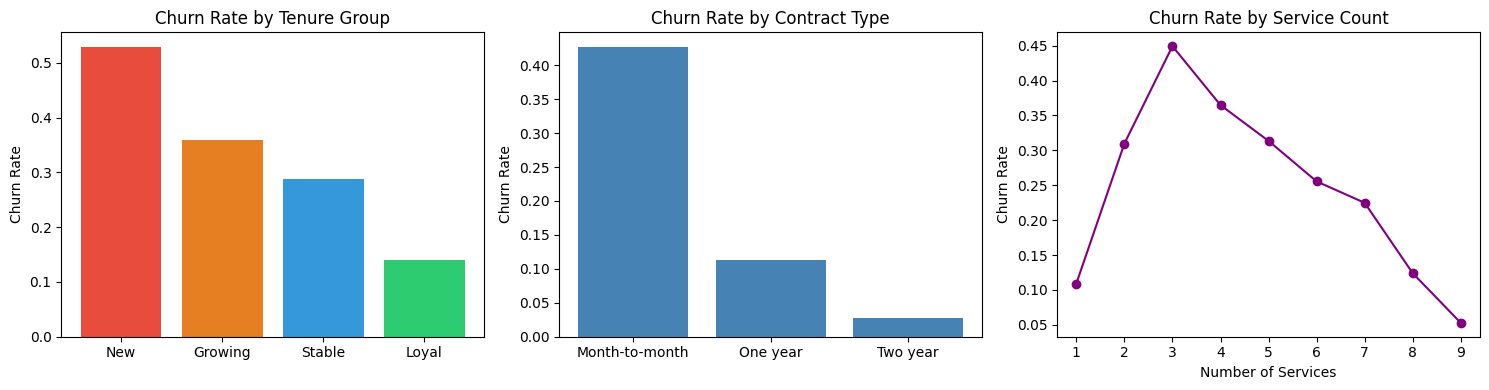

In [9]:
# Churn rate by tenure group
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Tenure group churn
tg_churn = df.groupby('TenureGroup')['Churn'].mean().reset_index()
tg_order = ['New', 'Growing', 'Stable', 'Loyal']
tg_churn['TenureGroup'] = pd.Categorical(tg_churn['TenureGroup'], categories=tg_order, ordered=True)
tg_churn = tg_churn.sort_values('TenureGroup')
axes[0].bar(tg_churn['TenureGroup'], tg_churn['Churn'], color=['#e74c3c','#e67e22','#3498db','#2ecc71'])
axes[0].set_title('Churn Rate by Tenure Group')
axes[0].set_ylabel('Churn Rate')

# Contract type churn
ct_churn = df.groupby('Contract')['Churn'].mean().reset_index()
axes[1].bar(ct_churn['Contract'], ct_churn['Churn'], color='steelblue')
axes[1].set_title('Churn Rate by Contract Type')
axes[1].set_ylabel('Churn Rate')

# Service count vs churn
sc_churn = df.groupby('ServiceCount')['Churn'].mean().reset_index()
axes[2].plot(sc_churn['ServiceCount'], sc_churn['Churn'], 'o-', color='purple')
axes[2].set_title('Churn Rate by Service Count')
axes[2].set_ylabel('Churn Rate')
axes[2].set_xlabel('Number of Services')

plt.tight_layout()
plt.show()


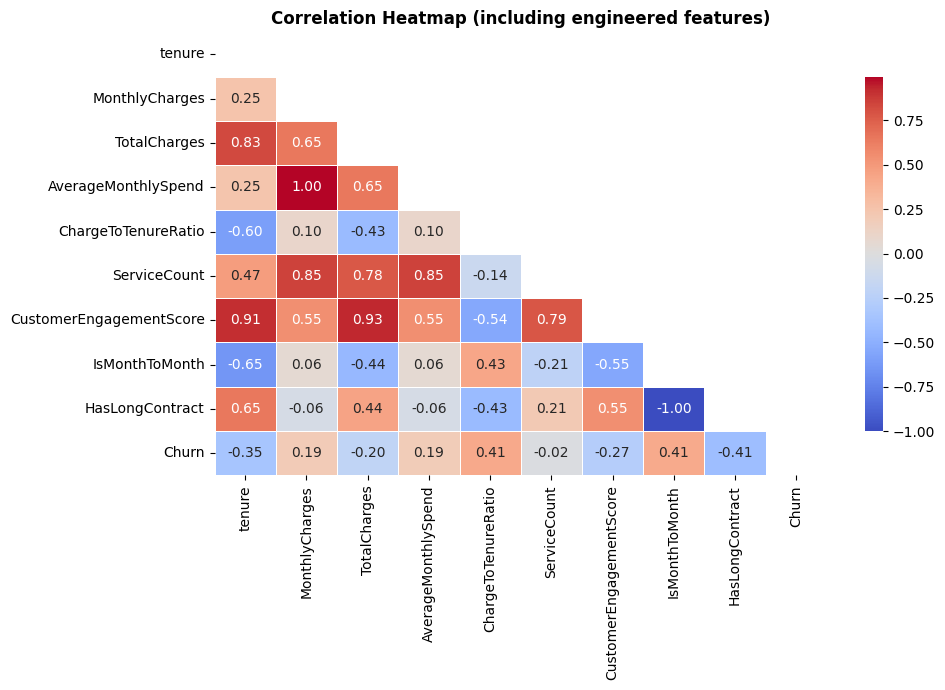

In [10]:
# Correlation heatmap — numerical features
num_cols_all = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AverageMonthlySpend',
                'ChargeToTenureRatio', 'ServiceCount', 'CustomerEngagementScore',
                'IsMonthToMonth', 'HasLongContract', 'Churn']

plt.figure(figsize=(10, 7))
corr = df[num_cols_all].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap (including engineered features)', fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Data Preprocessing — Encoding & Scaling

In [11]:
# ── 7.1  Label-encode categorical columns ─────────────────
object_columns = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", object_columns)

encoders = {}
for col in object_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

print("\n✅ Label encoding complete.")
df.head(3)


Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']

✅ Label encoding complete.


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,AverageMonthlySpend,ChargeToTenureRatio,ServiceCount,CustomerEngagementScore,IsMonthToMonth,HasLongContract,TenureGroup
0,0,0,1,0,1,0,1,0,0,2,...,29.85,29.85,0,29.850000,14.925000,2,0.057524,1,0,2
1,1,0,0,0,34,1,0,0,2,0,...,56.95,1889.50,0,55.573529,1.627143,4,0.362642,0,1,1
2,1,0,0,0,2,1,0,0,2,2,...,53.85,108.15,1,54.075000,17.950000,4,0.144486,1,0,2


In [12]:
# ── 7.2  Feature / Target split ──────────────────────────
X = df.drop(columns=['Churn'])
y = df['Churn']
feature_names = X.columns.tolist()
print(f"Features: {len(feature_names)}  |  Target distribution:\n{y.value_counts()}")


Features: 26  |  Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [13]:
# ── 7.3  Train / Test split ──────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")


Train: (5634, 26)  |  Test: (1409, 26)


In [14]:
# ── 7.4  SMOTE oversampling on training set ───────────────
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"After SMOTE — Train shape: {X_train_sm.shape}")
print(pd.Series(y_train_sm).value_counts())


After SMOTE — Train shape: (8278, 26)
Churn
0    4139
1    4139
Name: count, dtype: int64


In [15]:
# ── 7.5  StandardScaler ───────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)

print("✅ Scaling complete.")


✅ Scaling complete.


## 8. Hybrid Ensemble Model Training

In [16]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                                         random_state=42, verbosity=0),
    'LightGBM':            lgb.LGBMClassifier(random_state=42, verbose=-1)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("=" * 65)
for name, model in models.items():
    scores = cross_val_score(model, X_train_sc, y_train_sm,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:25s}  CV ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}")
print("=" * 65)


Logistic Regression        CV ROC-AUC: 0.9171 ± 0.0027
Random Forest              CV ROC-AUC: 0.9294 ± 0.0042
XGBoost                    CV ROC-AUC: 0.9287 ± 0.0047
LightGBM                   CV ROC-AUC: 0.9296 ± 0.0046


In [17]:
# ── Fit all models on full SMOTE-scaled training data ─────
trained_models = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train_sm)
    trained_models[name] = model
    print(f"✅ {name} trained.")


✅ Logistic Regression trained.
✅ Random Forest trained.
✅ XGBoost trained.
✅ LightGBM trained.


## 9. Model Evaluation & Comparison

In [18]:
results = []

for name, model in trained_models.items():
    y_pred  = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1]

    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
results_df = results_df.sort_values('ROC-AUC', ascending=False)
print(results_df.to_string())


                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.7672     0.5518  0.6551    0.5990   0.8379
LightGBM               0.7771     0.5739  0.6230    0.5974   0.8340
Random Forest          0.7828     0.5895  0.5989    0.5942   0.8278
XGBoost                0.7637     0.5522  0.5802    0.5658   0.8197


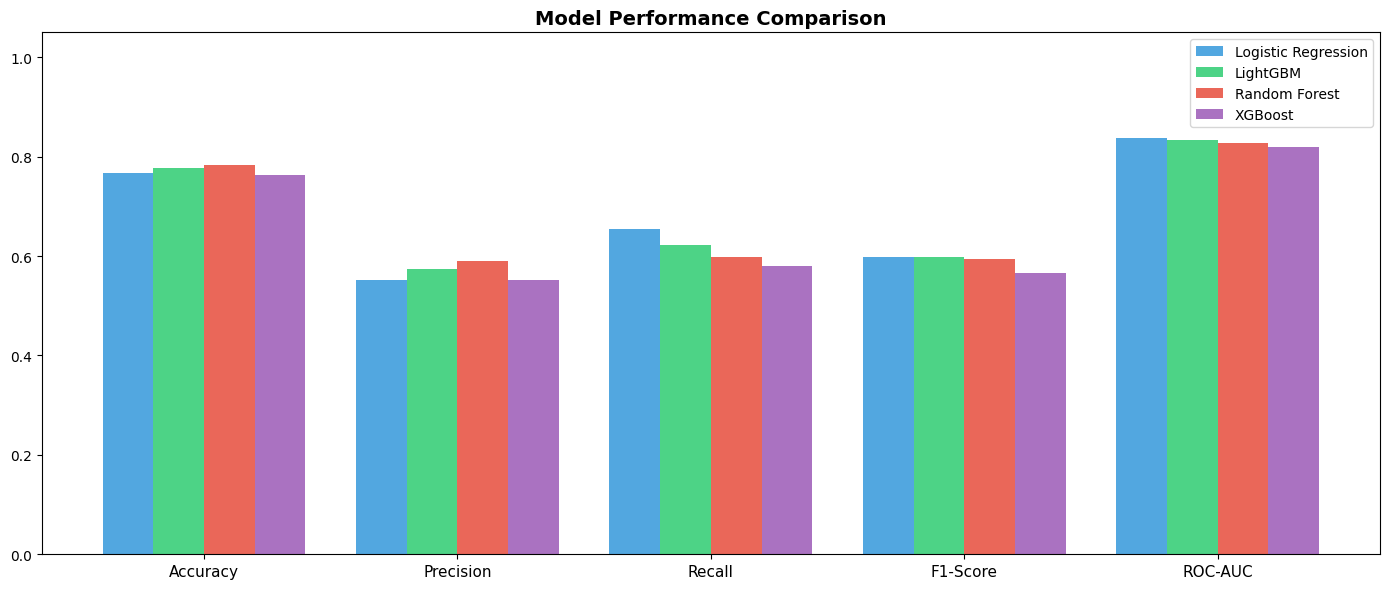

In [19]:
# ── Comparison bar chart ──────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.2
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (idx, row) in enumerate(results_df.iterrows()):
    ax.bar(x + i * width, [row[m] for m in metrics], width, label=idx, color=colors[i], alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


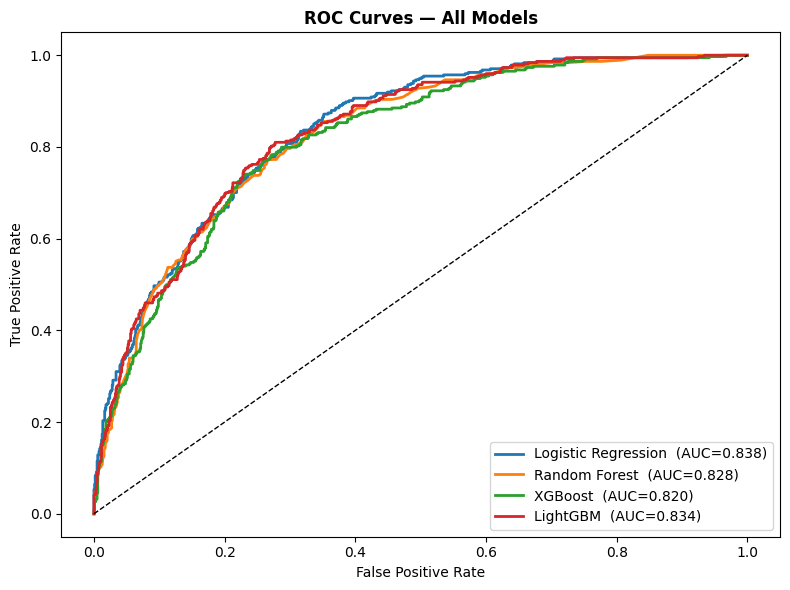

In [20]:
# ── ROC curves ───────────────────────────────────────────
plt.figure(figsize=(8, 6))
for name, model in trained_models.items():
    y_proba = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name}  (AUC={auc:.3f})', linewidth=2)

plt.plot([0,1],[0,1],'k--', linewidth=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()


In [21]:
# ── Select best model by ROC-AUC ─────────────────────────
best_model_name = results_df['ROC-AUC'].idxmax()
best_model      = trained_models[best_model_name]
print(f"🏆 Best model selected: {best_model_name}")
print(f"   ROC-AUC : {results_df.loc[best_model_name, 'ROC-AUC']:.4f}")
print(f"   F1-Score: {results_df.loc[best_model_name, 'F1-Score']:.4f}")


🏆 Best model selected: Logistic Regression
   ROC-AUC : 0.8379
   F1-Score: 0.5990


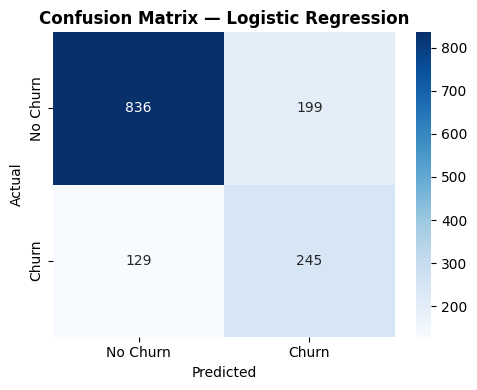


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.87      0.81      0.84      1035
       Churn       0.55      0.66      0.60       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.77      1409



In [22]:
# ── Confusion matrix for best model ──────────────────────
y_pred_best = best_model.predict(X_test_sc)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
plt.title(f'Confusion Matrix — {best_model_name}', fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['No Churn','Churn']))


## 10. Dynamic Churn Risk Scoring

In [26]:
def map_churn_risk(probability):
    pct = probability * 100

    if pct <= 30:
        return "Low Risk", "🟢"
    elif pct <= 70:
        return "Medium Risk", "🟠"
    else:
        return "High Risk", "🔴"


# Apply to entire test set
y_proba_best = best_model.predict_proba(X_test_sc)[:, 1]

risk_df = pd.DataFrame({
    'ChurnProbability': y_proba_best,
    'ChurnProbabilityPct': (y_proba_best * 100).round(2),
    'RiskLabel': [map_churn_risk(p) for p in y_proba_best],
    'ActualChurn': y_test.values
})

print("Risk Score Distribution:")
print(risk_df['RiskLabel'].value_counts())

risk_df.head(10)


Risk Score Distribution:
RiskLabel
(Low Risk, 🟢)       742
(Medium Risk, 🟠)    429
(High Risk, 🔴)      238
Name: count, dtype: int64


,ChurnProbability,ChurnProbabilityPct,RiskLabel,ActualChurn
0,0.043296,4.33,"(Low Risk, 🟢)",0
1,0.752739,75.27,"(High Risk, 🔴)",0
2,0.042535,4.25,"(Low Risk, 🟢)",0
3,0.440551,44.06,"(Medium Risk, 🟠)",0
4,0.032352,3.24,"(Low Risk, 🟢)",0
5,0.774887,77.49,"(High Risk, 🔴)",0
6,0.649975,65.00,"(Medium Risk, 🟠)",0
7,0.139917,13.99,"(Low Risk, 🟢)",0
8,0.003785,0.38,"(Low Risk, 🟢)",0
9,0.335188,33.52,"(Medium Risk, 🟠)",1


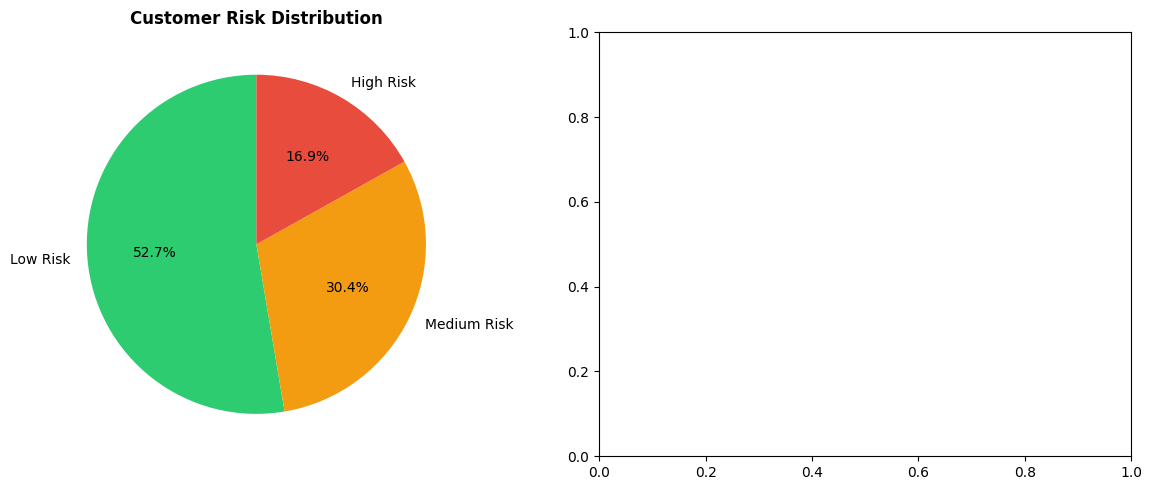

In [28]:
# Ensure only label strings are used
risk_df['RiskLabel'] = risk_df['RiskLabel'].apply(
    lambda x: x[0] if isinstance(x, tuple) else x
)

risk_counts = risk_df['RiskLabel'].value_counts()

colors_risk = {
    'Low Risk': '#2ecc71',
    'Medium Risk': '#f39c12',
    'High Risk': '#e74c3c'
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(
    risk_counts.values,
    labels=risk_counts.index,
    colors=[colors_risk[r] for r in risk_counts.index],
    autopct='%1.1f%%',
    startangle=90
)

axes[0].set_title('Customer Risk Distribution', fontweight='bold')

plt.tight_layout()
plt.show()


## 11. Explainable AI — SHAP Analysis

In [29]:
# ── 11.1  SHAP Explainer ─────────────────────────────────
print("Computing SHAP values (this may take ~30 seconds)...")

# Use TreeExplainer for tree-based models, LinearExplainer for LR
if best_model_name == 'Logistic Regression':
    explainer   = shap.LinearExplainer(best_model, X_train_sc)
    shap_values = explainer.shap_values(X_test_sc)
    sv = shap_values
else:
    explainer   = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_sc)
    # For binary classifiers some return list[2], take class-1
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

print("✅ SHAP values computed.")
print(f"   SHAP array shape: {np.array(sv).shape}")


Computing SHAP values (this may take ~30 seconds)...
✅ SHAP values computed.
   SHAP array shape: (1409, 26)


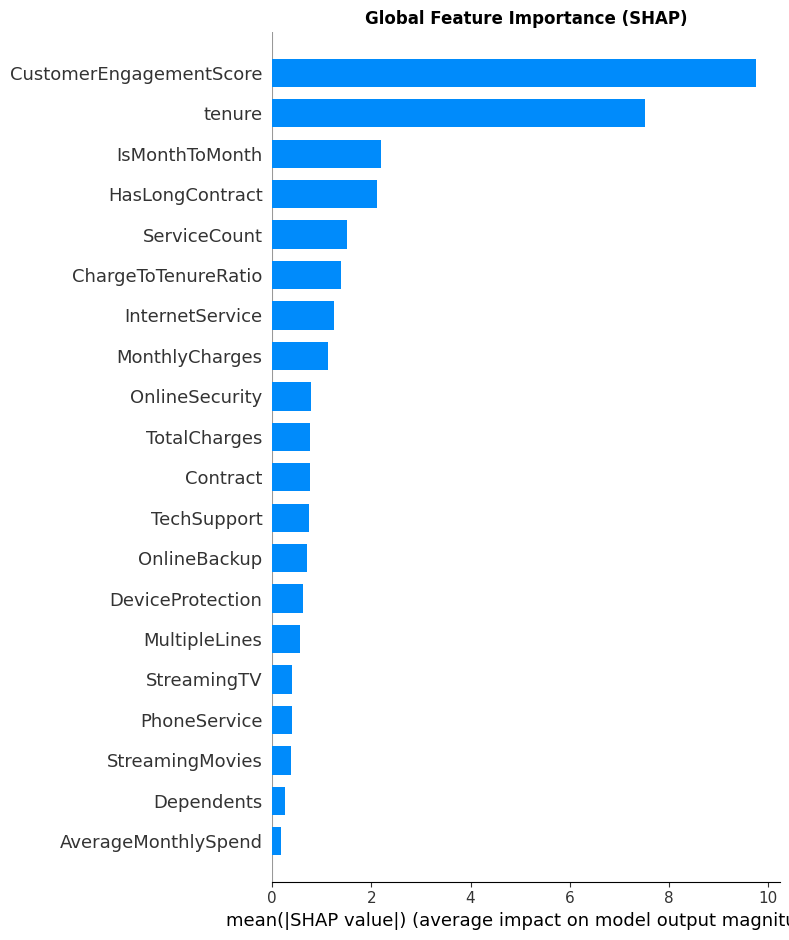

In [30]:
# ── 11.2  Global Feature Importance ─────────────────────
shap.summary_plot(sv, X_test, feature_names=feature_names,
                  plot_type='bar', show=False)
plt.title('Global Feature Importance (SHAP)', fontweight='bold')
plt.tight_layout(); plt.show()


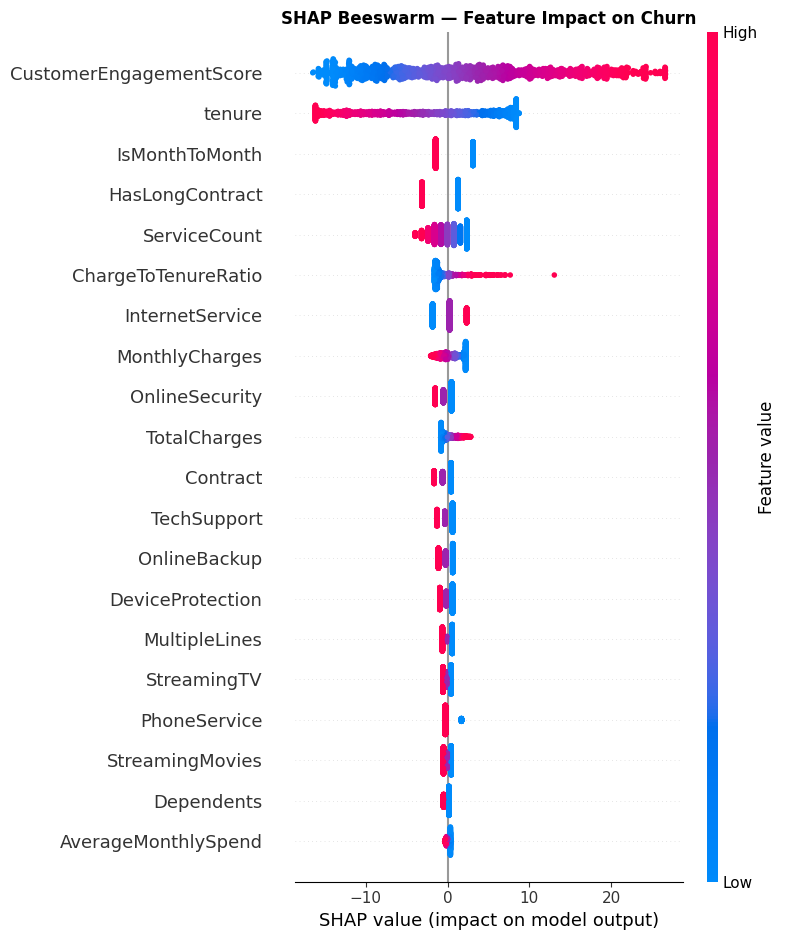

In [31]:
# ── 11.3  SHAP Beeswarm (impact direction) ───────────────
shap.summary_plot(sv, X_test, feature_names=feature_names, show=False)
plt.title('SHAP Beeswarm — Feature Impact on Churn', fontweight='bold')
plt.tight_layout(); plt.show()


Explaining prediction for test-set customer index 1
Churn Probability : 75.3%
Risk Label         : High Risk


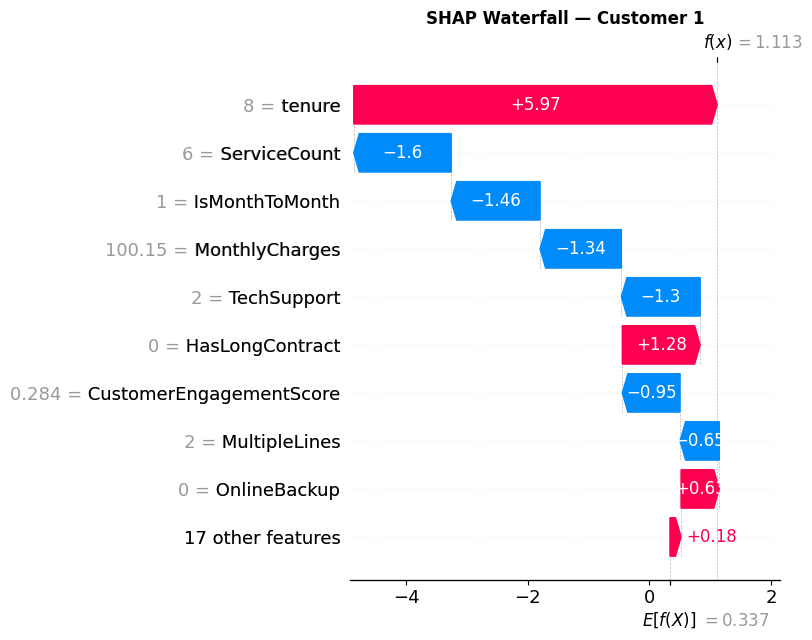

In [32]:
# ── 11.4  Customer-level SHAP explanation ────────────────
# Pick a high-risk customer from the test set for illustration
high_risk_idx = risk_df[risk_df['RiskLabel'] == 'High Risk'].index
if len(high_risk_idx) > 0:
    customer_idx = high_risk_idx[0]
    print(f"Explaining prediction for test-set customer index {customer_idx}")
    print(f"Churn Probability : {risk_df.loc[customer_idx, 'ChurnProbabilityPct']:.1f}%")
    print(f"Risk Label         : {risk_df.loc[customer_idx, 'RiskLabel']}")

    shap.waterfall_plot(
        shap.Explanation(
            values=sv[list(risk_df.index).index(customer_idx)],
            base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray))
                        else explainer.expected_value,
            data=np.array(X_test)[list(risk_df.index).index(customer_idx)],
            feature_names=feature_names
        ),
        show=False
    )
    plt.title(f'SHAP Waterfall — Customer {customer_idx}', fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    print("No high-risk customers found in test set for this run.")


In [34]:
# ── 11.5  Top-5 influential features per customer ────────
def top_shap_features(shap_vals_row, feature_names, n=5):
    """Return top-n features driving a prediction (sorted by |SHAP|)."""
    pairs = sorted(
        zip(feature_names, shap_vals_row),
        key=lambda x: abs(x[1]),
        reverse=True)
    return pairs[:n]

# Demo on first high-risk customer
if len(high_risk_idx) > 0:
    row_idx = list(risk_df.index).index(high_risk_idx[0])
    top5 = top_shap_features(sv[row_idx], feature_names)
    print("Top-5 features driving this customer's churn risk:")
    for feat, val in top5:
        direction = '⬆ increases' if val > 0 else '⬇ decreases'
        print(f"  {feat:30s}: SHAP={val:+.4f}  ({direction} churn risk)")


Top-5 features driving this customer's churn risk:
  tenure                        : SHAP=+5.9724  (⬆ increases churn risk)
  ServiceCount                  : SHAP=-1.6015  (⬇ decreases churn risk)
  IsMonthToMonth                : SHAP=-1.4600  (⬇ decreases churn risk)
  MonthlyCharges                : SHAP=-1.3366  (⬇ decreases churn risk)
  TechSupport                   : SHAP=-1.2952  (⬇ decreases churn risk)


## 12. Automated Personalized Retention Recommendation Engine

In [35]:
# ── Rule-based recommendation system ─────────────────────

RECOMMENDATIONS = {
    'high_charges': {
        'condition': lambda row: row['MonthlyCharges'] > 70,
        'action': '💰 Offer a 15% monthly discount or a bundled plan upgrade.',
        'reason': 'High monthly charges detected'
    },
    'low_tenure': {
        'condition': lambda row: row['tenure'] <= 6,
        'action': '🎁 Send a Welcome Retention Bonus: 1-month free or loyalty gift.',
        'reason': 'New customer (tenure ≤ 6 months)'
    },
    'no_tech_support': {
        'condition': lambda row: str(row.get('TechSupport','No')).lower() in ['no','0'],
        'action': '🔧 Offer 3 months of free Tech Support to improve satisfaction.',
        'reason': 'Customer has no Tech Support subscription'
    },
    'month_to_month': {
        'condition': lambda row: row.get('IsMonthToMonth', 0) == 1,
        'action': '📋 Incentivise switch to Annual Contract: 2 months free.',
        'reason': 'Month-to-month contract — highest churn risk type'
    },
    'low_services': {
        'condition': lambda row: row.get('ServiceCount', 10) < 3,
        'action': '📦 Upsell bundled services with a "More Value" promo package.',
        'reason': 'Low service count — low engagement'
    },
    'low_engagement': {
        'condition': lambda row: row.get('CustomerEngagementScore', 1) < 0.3,
        'action': '📣 Launch personalised re-engagement campaign via email/SMS.',
        'reason': 'Low customer engagement score'
    },
    'high_risk_default': {
        'condition': lambda row: True,   # always fires as fallback for high-risk
        'action': '🏆 Assign dedicated Loyalty Manager and offer VIP loyalty reward.',
        'reason': 'High-risk customer requires premium retention strategy'
    }
}

def generate_recommendations(customer_row, risk_label):
    """
    Input  : a dict/Series of raw (pre-encoded) customer features + engineered features,
             and the risk label string.
    Output : list of recommendation dicts {reason, action}.
    """
    recs = []
    rules_to_check = list(RECOMMENDATIONS.keys())

    # Only fire the high_risk_default for High Risk customers
    if risk_label != 'High Risk':
        rules_to_check.remove('high_risk_default')

    for rule_key in rules_to_check:
        rule = RECOMMENDATIONS[rule_key]
        try:
            if rule['condition'](customer_row):
                recs.append({'Reason': rule['reason'], 'Action': rule['action']})
        except Exception:
            pass

    if not recs:
        recs.append({'Reason': 'Satisfied customer', 'Action': '✅ No immediate action required. Monitor quarterly.'})

    return recs

print("✅ Recommendation engine defined.")


✅ Recommendation engine defined.


## 13. End-to-End Prediction + Recommendation Pipeline

In [36]:
def predict_and_recommend(raw_input_dict, trained_model, scaler,
                          encoders, feature_names, shap_explainer, shap_values_global):
    """
    Full pipeline:
      raw_input_dict → clean → encode → scale → predict → risk → SHAP → recommend

    Parameters
    ----------
    raw_input_dict : dict  — raw customer features (pre-encoding, same keys as training)
    trained_model  : fitted sklearn/xgb/lgb model
    scaler         : fitted StandardScaler
    encoders       : dict of {col: LabelEncoder}
    feature_names  : list of feature column names (post-encoding order)
    shap_explainer : fitted SHAP explainer
    shap_values_global : precomputed shap values array (for explainer.expected_value)

    Returns
    -------
    dict with keys: prediction, probability, risk_label, top_features, recommendations
    """
    # 1. Build DataFrame
    input_df = pd.DataFrame([raw_input_dict])

    # 2. Outlier-clip numerical cols (use same bounds — simplified to clamp)
    for col in ['MonthlyCharges', 'TotalCharges', 'tenure']:
        if col in input_df.columns:
            input_df[col] = pd.to_numeric(input_df[col], errors='coerce').fillna(0)

    # 3. Feature engineering
    input_df['AverageMonthlySpend'] = np.where(
        input_df['tenure'] > 0,
        input_df['TotalCharges'] / input_df['tenure'],
        input_df['MonthlyCharges']
    )
    input_df['ChargeToTenureRatio'] = input_df['MonthlyCharges'] / (input_df['tenure'] + 1)

    svc_cols = ['PhoneService','MultipleLines','InternetService','OnlineSecurity',
                'OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
    def _count(row):
        c = 0
        for col in svc_cols:
            if col in row.index:
                v = str(row[col]).strip().lower()
                if v not in ['no','no phone service','no internet service']:
                    c += 1
        return c
    input_df['ServiceCount'] = input_df.apply(_count, axis=1)

    input_df['CustomerEngagementScore'] = (
        (input_df['tenure'] / 72) * 0.4 +
        (input_df['ServiceCount'] / 9) * 0.4 -
        (input_df['ChargeToTenureRatio'] / 120) * 0.2
    )
    input_df['IsMonthToMonth'] = (input_df.get('Contract','') == 'Month-to-month').astype(int)
    input_df['HasLongContract'] = (input_df.get('Contract','').isin(['One year','Two year'])).astype(int)

    def _tg(t):
        if t <= 6: return 'New'
        elif t <= 12: return 'Growing'
        elif t <= 24: return 'Stable'
        else: return 'Loyal'
    if 'TenureGroup' not in input_df.columns:
        input_df['TenureGroup'] = input_df['tenure'].apply(_tg)

    # 4. Encode categorical columns
    for col, le in encoders.items():
        if col in input_df.columns:
            try:
                input_df[col] = le.transform(input_df[col].astype(str))
            except ValueError:
                input_df[col] = 0   # unseen category → default

    # 5. Align columns to training feature order
    for col in feature_names:
        if col not in input_df.columns:
            input_df[col] = 0
    input_df = input_df[feature_names]

    # 6. Scale
    input_scaled = scaler.transform(input_df)

    # 7. Predict
    prob       = trained_model.predict_proba(input_scaled)[0][1]
    prediction = int(prob >= 0.5)
    risk_label, risk_emoji = churn_risk_label(prob)

    # 8. SHAP explanation
    sv_row = shap_explainer.shap_values(input_scaled)
    sv_row = sv_row[1][0] if isinstance(sv_row, list) else sv_row[0]
    top5   = top_shap_features(sv_row, feature_names, n=5)

    # 9. Recommendations  — use raw dict enriched with engineered features
    enriched = raw_input_dict.copy()
    enriched.update({
        'MonthlyCharges':        float(input_df['MonthlyCharges'].iloc[0]),
        'tenure':                float(input_df['tenure'].iloc[0]),
        'ServiceCount':          int(input_df['ServiceCount'].iloc[0]),
        'CustomerEngagementScore': float(input_df['CustomerEngagementScore'].iloc[0]),
        'IsMonthToMonth':        int(input_df['IsMonthToMonth'].iloc[0]),
        'TechSupport':           raw_input_dict.get('TechSupport','No')
    })
    recs = generate_recommendations(enriched, risk_label)

    return {
        'Prediction':       'Churn' if prediction == 1 else 'No Churn',
        'ChurnProbability': f'{prob*100:.1f}%',
        'RiskLabel':        f'{risk_emoji} {risk_label}',
        'TopSHAPFeatures':  top5,
        'Recommendations':  recs
    }

print("✅ End-to-end pipeline function defined.")


✅ End-to-end pipeline function defined.


In [39]:
# ==========================================
# HELPER FUNCTIONS
# ==========================================

def churn_risk_label(probability):
    pct = probability * 100

    if pct <= 30:
        return "Low Risk", "🟢"
    elif pct <= 70:
        return "Medium Risk", "🟠"
    else:
        return "High Risk", "🔴"


def get_top_shap_features(feature_names, shap_vals_row, top_n=5):
    pairs = sorted(
        zip(feature_names, shap_vals_row),
        key=lambda x: abs(x[1]),
        reverse=True
    )
    return pairs[:top_n]

# ── Demo: Run pipeline on a sample customer ───────────────
sample_customer = {
    'gender':          'Female',
    'SeniorCitizen':   0,
    'Partner':         'Yes',
    'Dependents':      'No',
    'tenure':          1,
    'PhoneService':    'No',
    'MultipleLines':   'No phone service',
    'InternetService': 'DSL',
    'OnlineSecurity':  'No',
    'OnlineBackup':    'Yes',
    'DeviceProtection':'No',
    'TechSupport':     'No',
    'StreamingTV':     'No',
    'StreamingMovies': 'No',
    'Contract':        'Month-to-month',
    'PaperlessBilling':'Yes',
    'PaymentMethod':   'Electronic check',
    'MonthlyCharges':  29.85,
    'TotalCharges':    29.85
}

result = predict_and_recommend(
    sample_customer, best_model, scaler, encoders, feature_names, explainer, sv
)

print("=" * 60)
print("  CUSTOMER CHURN PREDICTION REPORT")
print("=" * 60)
print(f"  Prediction         : {result['Prediction']}")
print(f"  Churn Probability  : {result['ChurnProbability']}")
print(f"  Risk Level         : {result['RiskLabel']}")
print()
print("  Top Influential Features (SHAP):")
for feat, val in result['TopSHAPFeatures']:
    direction = '⬆' if val > 0 else '⬇'
    print(f"    {direction} {feat:30s}: {val:+.4f}")
print()
print("  Personalized Retention Recommendations:")
for i, rec in enumerate(result['Recommendations'], 1):
    print(f"  {i}. [{rec['Reason']}]")
    print(f"     → {rec['Action']}")
print("=" * 60)


  CUSTOMER CHURN PREDICTION REPORT
  Prediction         : Churn
  Churn Probability  : 85.4%
  Risk Level         : 🔴 High Risk

  Top Influential Features (SHAP):
    ⬇ CustomerEngagementScore       : -12.4440
    ⬆ tenure                        : +8.3932
    ⬇ InternetService               : -1.8317
    ⬆ MonthlyCharges                : +1.7722
    ⬆ PhoneService                  : +1.6902

  Personalized Retention Recommendations:
  1. [New customer (tenure ≤ 6 months)]
     → 🎁 Send a Welcome Retention Bonus: 1-month free or loyalty gift.
  2. [Customer has no Tech Support subscription]
     → 🔧 Offer 3 months of free Tech Support to improve satisfaction.
  3. [Month-to-month contract — highest churn risk type]
     → 📋 Incentivise switch to Annual Contract: 2 months free.
  4. [Low service count — low engagement]
     → 📦 Upsell bundled services with a "More Value" promo package.
  5. [Low customer engagement score]
     → 📣 Launch personalised re-engagement campaign via email/SMS

In [40]:
# ── Test multiple customer profiles ──────────────────────
test_profiles = [
    {   # High tenure, loyal customer
        'gender':'Male','SeniorCitizen':0,'Partner':'Yes','Dependents':'Yes',
        'tenure':60,'PhoneService':'Yes','MultipleLines':'Yes',
        'InternetService':'Fiber optic','OnlineSecurity':'Yes','OnlineBackup':'Yes',
        'DeviceProtection':'Yes','TechSupport':'Yes','StreamingTV':'Yes',
        'StreamingMovies':'Yes','Contract':'Two year','PaperlessBilling':'No',
        'PaymentMethod':'Bank transfer (automatic)','MonthlyCharges':95.0,'TotalCharges':5700.0
    },
    {   # New customer, month-to-month, high charges
        'gender':'Female','SeniorCitizen':1,'Partner':'No','Dependents':'No',
        'tenure':2,'PhoneService':'Yes','MultipleLines':'No',
        'InternetService':'Fiber optic','OnlineSecurity':'No','OnlineBackup':'No',
        'DeviceProtection':'No','TechSupport':'No','StreamingTV':'Yes',
        'StreamingMovies':'Yes','Contract':'Month-to-month','PaperlessBilling':'Yes',
        'PaymentMethod':'Electronic check','MonthlyCharges':110.0,'TotalCharges':220.0
    }
]

for i, profile in enumerate(test_profiles, 1):
    res = predict_and_recommend(
        profile, best_model, scaler, encoders, feature_names, explainer, sv)
    print(f"\n{'='*55}")
    print(f"  PROFILE {i} — {res['Prediction']}  |  {res['RiskLabel']}  |  Prob={res['ChurnProbability']}")
    print(f"{'='*55}")
    for rec in res['Recommendations']:
        print(f"  ▸ {rec['Action']}")



  PROFILE 1 — No Churn  |  🟢 Low Risk  |  Prob=6.6%
  ▸ 💰 Offer a 15% monthly discount or a bundled plan upgrade.

  PROFILE 2 — Churn  |  🔴 High Risk  |  Prob=96.8%
  ▸ 💰 Offer a 15% monthly discount or a bundled plan upgrade.
  ▸ 🎁 Send a Welcome Retention Bonus: 1-month free or loyalty gift.
  ▸ 🔧 Offer 3 months of free Tech Support to improve satisfaction.
  ▸ 📋 Incentivise switch to Annual Contract: 2 months free.
  ▸ 📣 Launch personalised re-engagement campaign via email/SMS.
  ▸ 🏆 Assign dedicated Loyalty Manager and offer VIP loyalty reward.


## 14. Save Model, Encoders & Scaler

In [41]:
# Save best model
model_data = {
    'model':         best_model,
    'model_name':    best_model_name,
    'feature_names': feature_names
}
with open('customer_churn_best_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

# Save encoders
with open('encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Saved:")
print("   customer_churn_best_model.pkl")
print("   encoders.pkl")
print("   scaler.pkl")


✅ Saved:
   customer_churn_best_model.pkl
   encoders.pkl
   scaler.pkl


## 15. Streamlit Web Application

Run the cell below to write the Streamlit app to `app.py`.  
Then launch with: `!streamlit run app.py &`


In [42]:
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import shap
import matplotlib.pyplot as plt

# ── Load artefacts ─────────────────────────────────────────
@st.cache_resource
def load_artefacts():
    with open("customer_churn_best_model.pkl", "rb") as f:
        md = pickle.load(f)
    with open("encoders.pkl", "rb") as f:
        enc = pickle.load(f)
    with open("scaler.pkl", "rb") as f:
        sc = pickle.load(f)
    return md["model"], md["model_name"], md["feature_names"], enc, sc

model, model_name, feature_names, encoders, scaler = load_artefacts()

# ── Page config ────────────────────────────────────────────
st.set_page_config(page_title="Churn Predictor", page_icon="📊", layout="wide")
st.title("📊 Customer Churn Prediction Dashboard")
st.caption(f"Model: {model_name}")

# ── Sidebar — Input Form ───────────────────────────────────
st.sidebar.header("Customer Information")
gender          = st.sidebar.selectbox("Gender", ["Female","Male"])
senior          = st.sidebar.selectbox("Senior Citizen", [0, 1])
partner         = st.sidebar.selectbox("Partner", ["Yes","No"])
dependents      = st.sidebar.selectbox("Dependents", ["No","Yes"])
tenure          = st.sidebar.slider("Tenure (months)", 0, 72, 12)
phone_service   = st.sidebar.selectbox("Phone Service", ["Yes","No"])
multiple_lines  = st.sidebar.selectbox("Multiple Lines", ["No","Yes","No phone service"])
internet        = st.sidebar.selectbox("Internet Service", ["DSL","Fiber optic","No"])
online_sec      = st.sidebar.selectbox("Online Security", ["No","Yes","No internet service"])
online_bk       = st.sidebar.selectbox("Online Backup", ["Yes","No","No internet service"])
device_prot     = st.sidebar.selectbox("Device Protection", ["No","Yes","No internet service"])
tech_support    = st.sidebar.selectbox("Tech Support", ["No","Yes","No internet service"])
streaming_tv    = st.sidebar.selectbox("Streaming TV", ["No","Yes","No internet service"])
streaming_mv    = st.sidebar.selectbox("Streaming Movies", ["No","Yes","No internet service"])
contract        = st.sidebar.selectbox("Contract", ["Month-to-month","One year","Two year"])
paperless       = st.sidebar.selectbox("Paperless Billing", ["Yes","No"])
payment         = st.sidebar.selectbox("Payment Method",
                    ["Electronic check","Mailed check","Bank transfer (automatic)","Credit card (automatic)"])
monthly_charges = st.sidebar.number_input("Monthly Charges ($)", 18.0, 120.0, 65.0)
total_charges   = st.sidebar.number_input("Total Charges ($)", 0.0, 9000.0, monthly_charges * tenure)

raw = dict(gender=gender, SeniorCitizen=senior, Partner=partner,
           Dependents=dependents, tenure=tenure, PhoneService=phone_service,
           MultipleLines=multiple_lines, InternetService=internet,
           OnlineSecurity=online_sec, OnlineBackup=online_bk,
           DeviceProtection=device_prot, TechSupport=tech_support,
           StreamingTV=streaming_tv, StreamingMovies=streaming_mv,
           Contract=contract, PaperlessBilling=paperless,
           PaymentMethod=payment, MonthlyCharges=monthly_charges,
           TotalCharges=total_charges)

if st.sidebar.button("🔍 Predict Churn"):
    # ── Run pipeline inline ────────────────────────────────
    import sys, os
    # (pipeline function is duplicated here for standalone app)
    from sklearn.preprocessing import LabelEncoder
    import warnings; warnings.filterwarnings("ignore")

    input_df = pd.DataFrame([raw])
    for col in ["MonthlyCharges","TotalCharges","tenure"]:
        input_df[col] = pd.to_numeric(input_df[col], errors="coerce").fillna(0)

    svc_cols = ["PhoneService","MultipleLines","InternetService","OnlineSecurity",
                "OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]
    def _cnt(row):
        c = 0
        for col in svc_cols:
            if col in row.index:
                v = str(row[col]).strip().lower()
                if v not in ["no","no phone service","no internet service"]: c += 1
        return c

    input_df["AverageMonthlySpend"] = np.where(input_df["tenure"]>0,
        input_df["TotalCharges"]/input_df["tenure"], input_df["MonthlyCharges"])
    input_df["ChargeToTenureRatio"] = input_df["MonthlyCharges"]/(input_df["tenure"]+1)
    input_df["ServiceCount"] = input_df.apply(_cnt, axis=1)
    input_df["CustomerEngagementScore"] = (
        (input_df["tenure"]/72)*0.4 + (input_df["ServiceCount"]/9)*0.4
        - (input_df["ChargeToTenureRatio"]/120)*0.2)
    input_df["IsMonthToMonth"] = (input_df["Contract"]=="Month-to-month").astype(int)
    input_df["HasLongContract"] = (input_df["Contract"].isin(["One year","Two year"])).astype(int)
    def _tg(t):
        return "New" if t<=6 else ("Growing" if t<=12 else ("Stable" if t<=24 else "Loyal"))
    input_df["TenureGroup"] = input_df["tenure"].apply(_tg)

    for col, le in encoders.items():
        if col in input_df.columns:
            try: input_df[col] = le.transform(input_df[col].astype(str))
            except: input_df[col] = 0
    for col in feature_names:
        if col not in input_df.columns: input_df[col] = 0
    input_df = input_df[feature_names]
    input_scaled = scaler.transform(input_df)

    prob = model.predict_proba(input_scaled)[0][1]
    pct  = prob * 100
    risk = "🟢 Low Risk" if pct<=30 else ("🟡 Medium Risk" if pct<=70 else "🔴 High Risk")

    # ── Layout ────────────────────────────────────────────
    col1, col2, col3 = st.columns(3)
    col1.metric("Prediction",   "⚠️ Churn" if prob>=0.5 else "✅ No Churn")
    col2.metric("Probability",  f"{pct:.1f}%")
    col3.metric("Risk Level",   risk)

    # Probability gauge
    st.subheader("Churn Probability Gauge")
    fig, ax = plt.subplots(figsize=(6,1))
    ax.barh(["Risk"], [pct], color="#e74c3c" if pct>70 else ("#f39c12" if pct>30 else "#2ecc71"), height=0.4)
    ax.barh(["Risk"], [100-pct], left=pct, color="#ecf0f1", height=0.4)
    ax.set_xlim(0,100); ax.set_xlabel("Churn Probability (%)"); ax.set_title(f"{pct:.1f}%")
    ax.axvline(30, color="orange", linestyle="--", linewidth=0.8)
    ax.axvline(70, color="red",    linestyle="--", linewidth=0.8)
    st.pyplot(fig)

    # SHAP
    st.subheader("🔍 SHAP Feature Explanation")
    try:
        explainer_s = shap.TreeExplainer(model)
        sv_s = explainer_s.shap_values(input_scaled)
        sv_row = sv_s[1][0] if isinstance(sv_s, list) else sv_s[0]
        feat_imp = pd.DataFrame({"Feature": feature_names, "SHAP": sv_row})
        feat_imp["Abs"] = feat_imp["SHAP"].abs()
        feat_imp = feat_imp.nlargest(10,"Abs")
        fig2, ax2 = plt.subplots(figsize=(8,4))
        colors2 = ["#e74c3c" if v>0 else "#2ecc71" for v in feat_imp["SHAP"]]
        ax2.barh(feat_imp["Feature"], feat_imp["SHAP"], color=colors2)
        ax2.set_xlabel("SHAP Value"); ax2.set_title("Top 10 SHAP Features")
        ax2.axvline(0, color="black", linewidth=0.8)
        st.pyplot(fig2)
    except Exception as e:
        st.warning(f"SHAP explanation unavailable: {e}")

    # Recommendations
    st.subheader("💡 Personalized Retention Recommendations")
    recs = []
    risk_label = "High Risk" if pct>70 else ("Medium Risk" if pct>30 else "Low Risk")
    if raw["MonthlyCharges"] > 70: recs.append(("High monthly charges","💰 Offer a 15% monthly discount or bundled plan."))
    if raw["tenure"] <= 6:         recs.append(("New customer","🎁 Send Welcome Retention Bonus: 1-month free."))
    if str(raw["TechSupport"]).lower() in ["no","0"]: recs.append(("No Tech Support","🔧 Offer 3 months free Tech Support."))
    if raw["Contract"] == "Month-to-month": recs.append(("Month-to-month contract","📋 Incentivise annual contract: 2 months free."))
    if risk_label == "High Risk": recs.append(("High Risk customer","🏆 Assign Loyalty Manager + VIP reward."))
    if not recs: recs.append(("Satisfied customer","✅ No immediate action needed. Monitor quarterly."))
    for reason, action in recs:
        st.info(f"**{reason}** → {action}")
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("✅ Streamlit app written to app.py")
print("   To launch: !streamlit run app.py &")


✅ Streamlit app written to app.py
   To launch: !streamlit run app.py &


## 16. System Architecture & Workflow Diagram

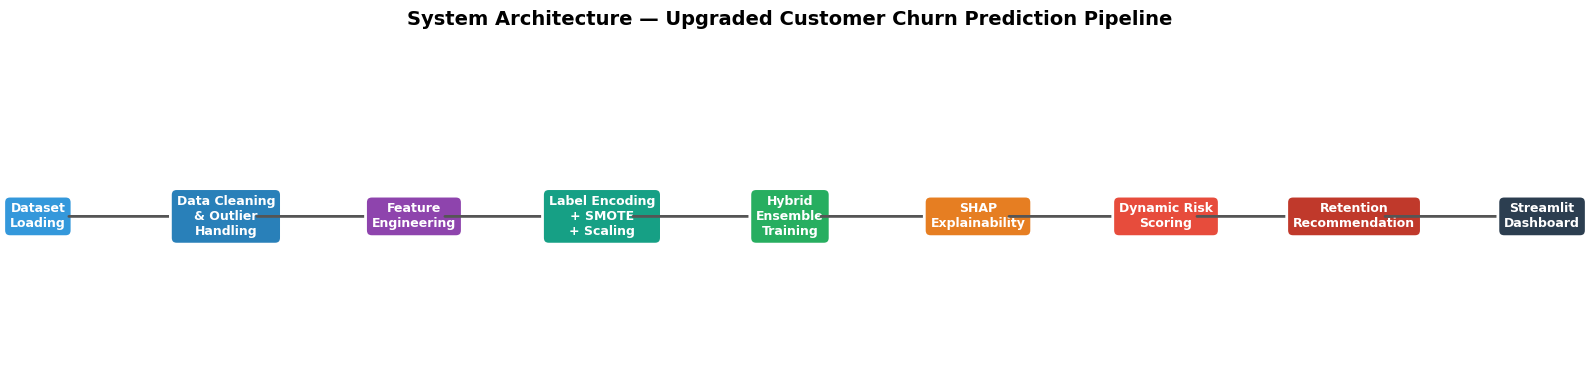

✅ Architecture diagram saved as architecture_diagram.png


In [43]:
fig, ax = plt.subplots(figsize=(16, 4))
ax.axis('off')

boxes = [
    ('Dataset\nLoading', '#3498db'),
    ('Data Cleaning\n& Outlier\nHandling', '#2980b9'),
    ('Feature\nEngineering', '#8e44ad'),
    ('Label Encoding\n+ SMOTE\n+ Scaling', '#16a085'),
    ('Hybrid\nEnsemble\nTraining', '#27ae60'),
    ('SHAP\nExplainability', '#e67e22'),
    ('Dynamic Risk\nScoring', '#e74c3c'),
    ('Retention\nRecommendation', '#c0392b'),
    ('Streamlit\nDashboard', '#2c3e50')
]

n = len(boxes)
for i, (label, color) in enumerate(boxes):
    x = i / (n - 1)
    ax.text(x, 0.5, label, ha='center', va='center', fontsize=9,
            fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.5', facecolor=color, edgecolor='white', linewidth=2),
            transform=ax.transAxes)
    if i < n - 1:
        ax.annotate('', xy=((i + 0.85) / (n - 1), 0.5),
                    xytext=((i + 0.15) / (n - 1), 0.5),
                    xycoords='axes fraction', textcoords='axes fraction',
                    arrowprops=dict(arrowstyle='->', color='#555', lw=2))

ax.set_title('System Architecture — Upgraded Customer Churn Prediction Pipeline',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('architecture_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Architecture diagram saved as architecture_diagram.png")


## 17. Novelty Section — For Journal & Patent

### 17.1 System Novelties

| # | Module | Novel Contribution |
|---|--------|-------------------|
| 1 | **Explainable AI Integration** | SHAP-based per-customer explanation of churn drivers, producing auditable, interpretable outputs beyond black-box prediction |
| 2 | **Personalized Recommendation Engine** | Rule-based decision system that maps SHAP-identified churn causes to specific, actionable business retention strategies |
| 3 | **Dynamic Risk Scoring** | Continuous churn probability mapped to a 3-tier risk band (Low / Medium / High), enabling tiered intervention strategies |
| 4 | **Hybrid Ensemble Architecture** | Comparative training of RF + XGBoost + LightGBM + LR with SMOTE balancing and stratified cross-validation, with automated best-model selection |
| 5 | **Feature Engineering Pipeline** | Novel composite features (CustomerEngagementScore, AverageMonthlySpend, ServiceCount) capturing latent behavioural signals |

---

### 17.2 Patent Claims (Draft)

**Claim 1 — Prediction Engine**  
A computer-implemented method for predicting customer churn comprising: loading customer data, applying IQR-based outlier handling, generating engineered composite features, training a hybrid ensemble of classifiers with synthetic minority oversampling, and selecting the optimal model by ROC-AUC.

**Claim 2 — Explanation Module**  
A system for generating customer-specific churn explanations using SHAP (SHapley Additive exPlanations) values, producing a ranked list of features that increase or decrease churn probability for each individual customer.

**Claim 3 — Recommendation Engine**  
A rule-based recommendation engine that receives a churn risk score and SHAP-identified churn drivers as input, applies business-logic rules, and outputs personalized retention actions including discount offers, service upgrades, contract incentives, and loyalty programs.

**Claim 4 — Risk Scoring System**  
A dynamic churn risk scoring system that converts model output probabilities into categorical risk bands and applies differentiated retention strategies per band.

**Claim 5 — End-to-End Pipeline**  
An integrated pipeline combining data ingestion, preprocessing, model inference, SHAP explanation, risk scoring, and retention recommendation in a single callable function, deployable via a web application interface.

---

### 17.3 Architecture Summary

```
Raw Customer Data
       │
       ▼
Data Cleaning & Outlier Capping (IQR)
       │
       ▼
Feature Engineering
(AverageMonthlySpend, ServiceCount, CustomerEngagementScore,
 TenureGroups, ContractIndicators, ChargeToTenureRatio)
       │
       ▼
Label Encoding + SMOTE + StandardScaler
       │
       ▼
Hybrid Ensemble Training
(Logistic Regression | Random Forest | XGBoost | LightGBM)
       │
       ▼
Best Model Selection (ROC-AUC)
       │
       ├──▶ Dynamic Risk Score (Low / Medium / High)
       │
       ├──▶ SHAP Explainability
       │        ├── Global Feature Importance
       │        └── Customer-level Waterfall
       │
       └──▶ Retention Recommendation Engine
                └── Personalized Business Actions
                         │
                         ▼
              Streamlit Web Dashboard
```


## 18. Final System Summary

In [ ]:
print("=" * 65)
print("  UPGRADED CUSTOMER CHURN PREDICTION SYSTEM — SUMMARY")
print("=" * 65)
print(f"  Dataset            : 7,043 customers | 20 raw features")
print(f"  Engineered Features: 7 new derived features added")
print(f"  Class Balancing    : SMOTE applied")
print(f"  Models Evaluated   : Logistic Regression, Random Forest,")
print(f"                       XGBoost, LightGBM")
print()
print("  Model Performance (Test Set):")
print(results_df[['Accuracy','Precision','Recall','F1-Score','ROC-AUC']].to_string())
print()
print(f"  Best Model         : {best_model_name}")
print(f"  Explainability     : SHAP (global + per-customer)")
print(f"  Risk Scoring       : Low / Medium / High bands")
print(f"  Recommendations    : Rule-based personalized retention")
print(f"  Deployment         : Streamlit web app (app.py)")
print(f"  Saved Artefacts    : customer_churn_best_model.pkl")
print(f"                       encoders.pkl | scaler.pkl")
print("=" * 65)
